<a href="https://colab.research.google.com/github/marioarsw/AnaliticaDescriptiva/blob/main/practicas/practica8_267370.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos


*   Curso: Programación para Analítica Descriptiva y Predictiva
*   Semestre: Enero-Junio
*   Profesor: Dr. Vicente García Jiménez



## Práctica 7: Análisis de un Dataset con Seaborn y Visualización Avanzada

## Mario Amador - 267370.

* Objetivo:
Este ejercicio tiene como objetivo que los estudiantes aprendan a trabajar con seaborn para crear visualizaciones más avanzadas utilizando gráficos como el mapa de calor y el diagrama de violín. También, se les anima a explorar el dataset, hacer análisis descriptivos y aprender a interpretar los resultados.

*Dataset:
En este caso, vamos a utilizar el dataset de "tips" de seaborn, que contiene información sobre las propinas que dejaron los clientes en un restaurante, junto con detalles sobre el total de la cuenta, el día de la semana, si fue almuerzo o cena, entre otros. Para ello, los estudiantes podran cargar el dataset de la siguiente forma

`import seaborn as sns df = sns.load_dataset('tips')`

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Carga y exploración del dataset:

* Cargar el dataset tips usando seaborn.
* Realizar un análisis preliminar: utiliza .head(), .info(), .describe() para obtener una visión general de los datos.
* Verificar la existencia de valores nulos o datos faltantes.

In [5]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
tips.shape
# 244 registros, 7 columnas

(244, 7)

In [7]:
tips.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [8]:
tips.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [9]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [10]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [11]:
# Ver especies disponibles
# iris['species'].unique()
tips['day'].value_counts()

,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


In [12]:
# Encontrar valores nulos a lo largo de las diferentes columnas
tips.isnull().sum()


,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


# Mapa de Calor (Heatmap)

* Objetivo: Visualizar la correlación entre las variables numéricas en el dataset.
* Instrucciones: Utiliza un mapa de calor para mostrar la matriz de correlación entre las variables numéricas (**total_bill, tip, size**).
Asegúrate de personalizar el mapa con una paleta de colores y etiquetas en los ejes.

### Notas
La correlación mide qué tan relacionadas están dos variables numéricas y en qué dirección:

* Correlación positiva > 0:
    * Suben juntas
    * Ejemplo: Cuenta grande -> propina grande
* Correlación negativa < 0:
    * Una sube, la otra baja
* Correlación cercana a 0:
    * No hay relación clara

**Los valores siempre van entre -1 y 1.**

Una regla que puede servir para interpretar los valores:

0.0 – 0.3 → débil

0.3 – 0.6 → moderada

\> 0.6 → fuerte

### **Calcula la correlación de Pearson**
* Usa cada una de las filas y las compara columna a columna con la correlación de pearson.
* La diagonal principal siempre es 1 porque se hace la correlación consigo misma

Responde preguntas como:
*¿La propina depende más de la cuenta o del número de personas?
*¿Hay variables redundantes?
*¿Vale la pena usar una variable para predicción?

En este caso por ejemplo:
* El **tip** está más relacionada con **total_bill** que con **size**

In [13]:
corr_matrix = tips[['total_bill', 'tip', 'size']].corr()
corr_matrix

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


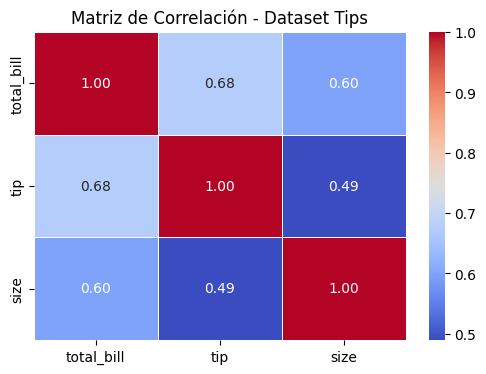

In [14]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_matrix,
    annot=True,          # Muestra los valores numéricos
    cmap='coolwarm',     # Paleta de colores
    fmt=".2f",           # Formato con 2 decimales
    linewidths=0.5
)

plt.title('Matriz de Correlación - Dataset Tips')
plt.show()

# Diagrama de Violín 🎻

* Objetivo: Mostrar la distribución de las propinas (tip) para diferentes días de la semana.
* Instrucciones: Utiliza un diagrama de violín para comparar cómo varía la distribución de las propinas en cada uno de los días (day).
Personaliza el gráfico con colores y etiquetas adecuadas.

### Notas
* Es una combinación entre boxplot (mediana y dispersión)
* Y distribición de densidad (qué valores son más frecuentes)

/tmp/ipython-input-529040486.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


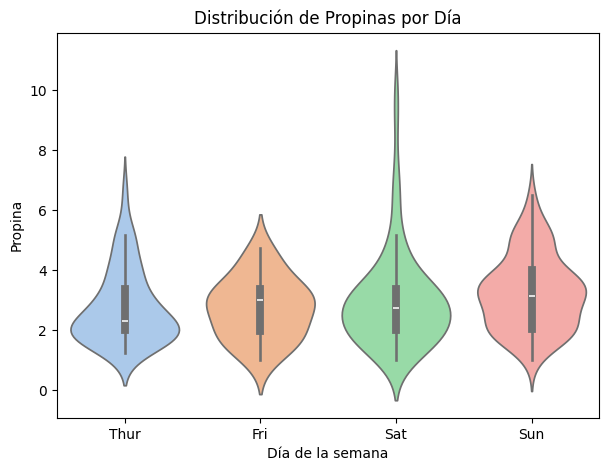

In [15]:
plt.figure(figsize=(7, 5))

sns.violinplot(
    x='day',
    y='tip',
    data=tips,
    palette='pastel'
)

plt.title('Distribución de Propinas por Día')
plt.xlabel('Día de la semana')
plt.ylabel('Propina')
plt.show()

El diagrama de violín muestra que las propinas tienden a ser más bajas y homogéneas entre semana, especialmente los jueves. En contraste, los fines de semana, particularmente el sábado, presentan una mayor variabilidad y la aparición de propinas significativamente más altas, lo que sugiere un comportamiento más heterogéneo de los clientes.

# Gráfico de dispersión (Scatter Plot)

* Objetivo: Analizar la relación entre el total de la cuenta (total_bill) y la propina (tip).
* Instrucciones: Crea un gráfico de dispersión con total_bill en el eje X y tip en el eje Y. Usa un color diferente para cada día de la semana.

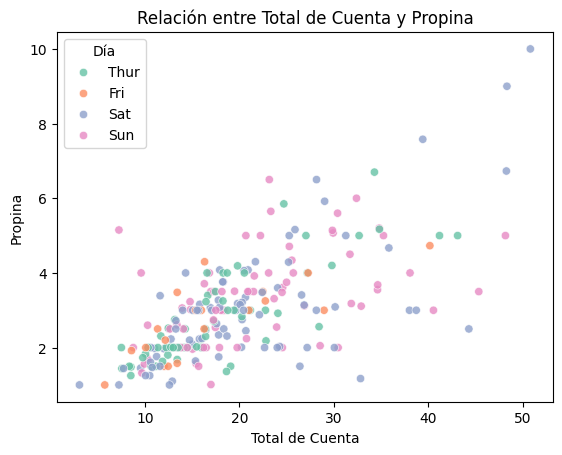

In [21]:
sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='day',        # Color por día
    palette='Set2',
    alpha=0.8         # Transparencia
)

plt.title('Relación entre Total de Cuenta y Propina')
plt.xlabel('Total de Cuenta')
plt.ylabel('Propina')
plt.legend(title='Día')
plt.show()

El gráfico de dispersión muestra una relación positiva entre el total de la cuenta y la propina, lo que indica que, en general, cuentas más altas se asocian con propinas mayores. Esta relación se mantiene en todos los días de la semana, aunque durante el fin de semana, especialmente el sábado, se observa una mayor variabilidad tanto en el total de la cuenta como en las propinas.

# Gráfico de barras (Bar Plot)

* Objetivo: Comparar el promedio de la propina (tip) por género (sex).
* Instrucciones: Utiliza un gráfico de barras para mostrar el promedio de las propinas por género (hombres y mujeres).

/tmp/ipython-input-3582500992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


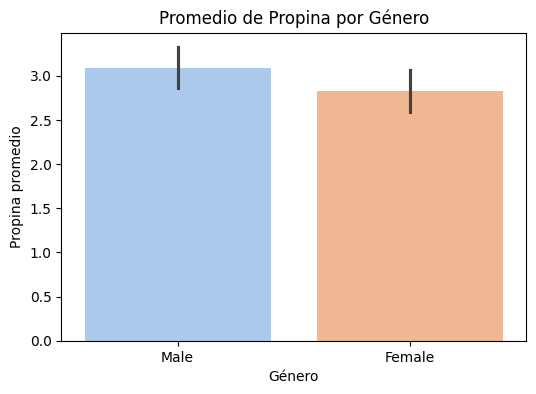

In [22]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x='sex',
    y='tip', # Seaborn calcula el promedio por defecto de esta columna
    data=tips,
    palette='pastel'
)

plt.title('Promedio de Propina por Género')
plt.xlabel('Género')
plt.ylabel('Propina promedio')
plt.show()

En promedio, se puede decir que los hombres pagan un poco más que las mujeres. Las líneas negras que aparecen indican que existe incertidumbre al calcular el promedio, es decir, se refiere a qué no sabemos el valor exacto del promedio real, ya que esto es solo una estimación basada en una muestra (No tenemos todas las propinas del mundo).

# Conclusión de todo lo utilizado

## 🔥 1. Mapa de calor (Heatmap)

* Permite visualizar la correlación entre variables numéricas, es decir, qué tan relacionadas están entre sí.
* Existió una correlación positiva entre el total de la cuenta *total_bill* y la propina *tip*.

**Cuándo usarlo:**

Para detectar relaciones entre variables numéricas.

Como paso previo a modelos predictivos o análisis más profundos.

## 🎻 2. Diagrama de violín (Violin Plot)

* Muestra la distribución completa de una variable numérica según una categoría.
* Las propinas fueron más variables durante el fin de semana, especialmente el sábado.
* Entre semana las propinas fueron más bajas y homogéneas.
* La posición de la mediana evidenció distribuciones asimétricas.

**Cuándo usarlo:**

Para comparar cómo se distribuyen los datos entre grupos.
Cuando interesa ver más que solo un promedio.

## 📊 3. Gráfico de dispersión (Scatter Plot)

* Analiza la relación entre dos variables numéricas a nivel de observación individual.

* A mayor total de la cuenta, mayor propina.

* Esta relación se mantuvo en todos los días de la semana.

* El fin de semana presentó mayor dispersión de valores.

**Cuándo usarlo:**

Para identificar tendencias, patrones y valores atípicos.
Para confirmar visualmente correlaciones detectadas previamente.

## 📊 4. Gráfico de barras (Bar Plot)

* Compara valores promedio de una variable numérica entre categorías.
*El promedio de propina fue ligeramente mayor en hombres que en mujeres.
* Los intervalos de confianza mostraron la incertidumbre de estas estimaciones.

**Cuándo usarlo:**

Para comparar promedios entre grupos.
Siempre considerando los intervalos de confianza, no solo la altura de la barra.